In [11]:
# !pip install uproot
# !pip install awkward
# !pip install matplotlib

In [12]:
# Get the file at wget https://opendata.cern.ch/record/30525/files/assets/cms/Run2016G/JetHT/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/130000/CD205112-3009-AB40-ACE1-9C3C31285B4A.root

In [117]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import vector

In [14]:
file = uproot.open('data.root')
file

<ReadOnlyDirectory '/' at 0x7f2ab1da2870>

In [15]:
file.keys()

['tag;1',
 'Events;1',
 'LuminosityBlocks;1',
 'Runs;1',
 'MetaData;1',
 'ParameterSets;1']

In [140]:
#file['Events'].keys()

In [28]:
branch = file['Events/Jet_mass'].array()
branch

<Array [[34.9, 32.5, 12.4, ..., 5.43, 3.67], ...] type='107505 * var * float32'>

In [21]:
flatten_jet_mass = ak.flatten(branch) # Making it 1D so we can graph it
flatten_jet_mass

<Array [34.9, 32.5, 12.4, 5.59, ..., 4.56, 45.7, 68.6] type='749311 * float32'>

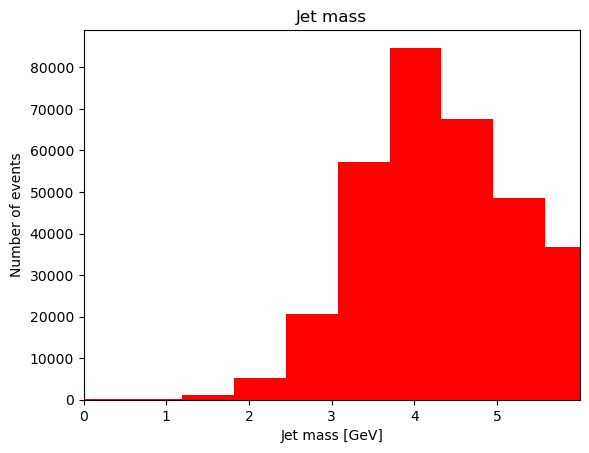

In [63]:
plt.hist(flatten_jet_mass,bins = 500, color = 'r')
plt.title('Jet mass')
plt.ylabel('Number of events')
plt.xlabel('Jet mass [GeV]')
#plt.yscale('log')
plt.xlim(0,6)
plt.xticks(np.arange(0,6,1))
plt.show()

In [114]:
%%time
# Printing all values with jet mass between 3.768 GeV and 4.396 GeV (got this numbers from binning...)

a=0

for i in flatten_jet_mass:
    if i > 3.768 and i < 4.396:
        a += 1
        
print(a)

84250
CPU times: user 902 ms, sys: 62 µs, total: 902 ms
Wall time: 905 ms


In [115]:
%%time

first_part = branch > 3.768
first_part = branch[first_part]

second_part = first_part < 4.396
full_jet_mass_cut = first_part[second_part]

print(np.sum(second_part))
print(len(ak.flatten(full_jet_mass_cut)))
print('Yay, the two numbers agree')

84250
84250
Yay, the two numbers agree
CPU times: user 22.8 ms, sys: 6.85 ms, total: 29.7 ms
Wall time: 28.7 ms


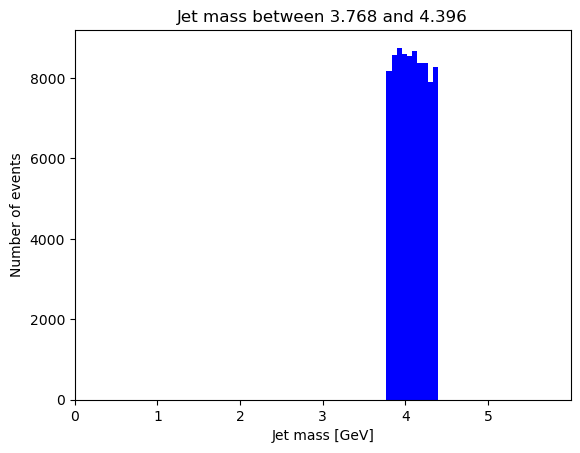

In [113]:
plt.hist(ak.flatten(full_jet_mass_cut), color ='b')
plt.title('Jet mass between 3.768 and 4.396')
plt.ylabel('Number of events')
plt.xlabel('Jet mass [GeV]')
#plt.yscale('log')
plt.xlim(0,6)
plt.xticks(np.arange(0,6,1))
plt.show()

In [143]:
jet_n = file['Events/nJet'].array()
jet_pt = file['Events/Jet_pt'].array()
jet_eta = file['Events/Jet_eta'].array()
jet_phi = file['Events/Jet_phi'].array()
jet_mass = file['Events/Jet_mass'].array()

In [185]:
# The following information *must* go inside .zip in order to work (order does not matter).
jet_p4 = vector.zip({'pt': jet_pt,
                     'eta': jet_eta,
                     'phi': jet_phi,
                     'mass': jet_mass})

In [186]:
# Applying cut -- only two jets:
dijet = jet_p4[jet_n == 2]              # What we are doing here is creating a list of true and false and assigning 
                                        # each to the "list" of jet_p4. We only keep the ones with true!

# Accessing properties by doing .pt, .eta, .phi, and .mass. Additionally, we can also use .px, .py, .pz, .E, etc.
dijet.E

<Array [[67.5, 32.2], ..., [1.3e+03, 1.4e+03]] type='3453 * var * float32'>